# max_peaks=50, three rankers (tm_score, chromatin_od, od_contrast) -- precision@K (K = 10, 20, 30) and re-ranking overhead

**What this notebook is.** `chromatin_od_ranker_variant.ipynb` (this same directory) fixed
`max_peaks=100` -- D9's accepted production value (`DECISIONS.md`) -- in both of its branches and
ablated the ranking criterion applied to the resulting ~90-99-candidate post-NMS pool:
`tm_score` (`TM_CCOEFF`, free) vs. `chromatin_od` (`od51` -- `midog_utils.chromatin.chromatin_density`,
window=51, darkest-10%). This notebook asks two further questions at once: **(1)** what happens if
the pre-NMS cap is cut further, to **50**, and **(2)** how does a third ranking axis,
**`od_contrast`** (`od51 - od_ctx`, `DECISIONS.md` D5's chromatin-axis family;
`latency_profiling/od_contrast_latency_profile.ipynb` profiled it on the *unbounded* pool),
compare at that same cap. `max_peaks=50` is explored here as a further ablation, **not** a proposed
change to D9's adopted 100.

**Branch structure.** The ranking criterion cannot change which candidates survive extraction and
NMS -- only the order they come out in -- so stages 1-5 (search through NMS, `max_peaks=50` applied
once) run **once** per ROI, and only stage 6 forks three ways: `t6` (sort by `score`, free), `t6a-c`
(pad at 25px, compute `od51`, sort), `t7a-e` (pad at 60px, compute `od51` *and* `od_ctx` from that
wider pad, subtract, sort). Each of the two chromatin arms computes its own feature(s)
independently -- an adopter of `od_contrast` alone would not also pay for `chromatin_od` as a
separate feature, and vice versa -- so nothing is shared between them beyond the common `pool`.

**Everything else is held fixed at production's accepted defaults** (`D8_TEMPLATE_ANCHOR.md`,
current as of 2026-09-10): `hematoxylin_od` channel, `TM_CCOEFF` (unnormalized), single-scale/
single-angle/no-flip augmentation, `peak_min_distance=7`, `self_hit_radius=5.0`, NMS radius = match
radius = `ev.MIDOG_RADIUS_UM` (7.5 um, D7 -- read from the module constant, not hardcoded, so a
stale override can't silently propagate), the same 14 ROIs, one seed per ROI,
`tightened_template_box` seed refinement, one `matchTemplate` pass per ROI shared by all three arms.

**od_contrast, defined precisely** (copied verbatim from `od_contrast_latency_profile.ipynb`):
`od_contrast = od51 - od_ctx`, where both are `chromatin.chromatin_density(hem_pad, x, y, window,
frac)` -- `od51` at `window=51, frac=0.10` (default), `od_ctx` at `window=121, frac=0.50`. Padding
uses `OD_PAD_CTX = 60` (covers the larger 121px window) for *both* components of this arm, since
that is what the source notebook does: pad once at the wider width, compute both components from
it. `chromatin_od`'s own pad stays at `OD_PAD_51 = 25` (exactly covers its 51px window) --
independent of `od_contrast`'s pad, since the two arms do not share intermediate values.

**Verification.** No notebook in this repo has run `max_peaks=50` before, so there is no oracle
CSV for the exact (cap, arm) combination under test here -- unlike the `max_peaks=100` case, where
`max_peaks_100_variant.ipynb` had already computed the `tm_score` branch independently. What *can*
be checked, and is checked below: (1) every column that stages 1-3 produce is independent of
`MAX_PEAKS` entirely (seed, box, match statistics), so those must match `chromatin_od_ranker_timing.csv`'s
already-committed `max_peaks=100` run exactly; (2) the cap itself must bind (`n_peaks == 50`); (3) a
real structural invariant -- greedy NMS in descending-score order (`midog_utils/nms.py`) never
revisits a decision based on a lower-scoring point, and `extract_peaks`'s global sort is a stable
prefix independent of `max_peaks` -- so the `max_peaks=50` post-NMS pool must equal the
`max_peaks=100` post-NMS pool restricted to raw score rank < 50. This is checked directly per ROI,
not assumed from the derivation.

**A note on `check_no_cap` (read this before changing `caps=` anywhere below).**
`chromatin_od_ranker_variant.ipynb` passes `caps=(MAX_PEAKS,)` to each `Arm`; at `max_peaks=100` the
post-NMS pool ran 89-99, never near 100, so `invariants.check_no_cap`'s exact-equality check never
fired. At `max_peaks=50`, the post-NMS pool runs close to 50 (only NMS + self-hit shrink it further
from a much smaller pre-NMS set), and `check_no_cap` **raises** on exact equality rather than
returning a failed record -- a zero-suppression-loss ROI would crash the run on a perfectly correct
result. `MAX_PEAKS` bounds the *pre-NMS* peak count, not the post-NMS candidate frame these arms
return, so it does not belong in `caps` here; the real "does the cap bind" check is the direct
`assert n_peaks == MAX_PEAKS` after extraction, which inspects the count `caps` cannot see.

**On single-shot timing noise.** The 2026-09-12 audit of `chromatin_od_ranker_variant.ipynb`
(`Research Logs/2026-09-12-chromatin-od-ranker-variant-audit.md`, Finding 3) found a single
`cv2.copyMakeBorder` call can run 1.09x-3.5x its own median, inflating a single-shot mean by ~40%.
This notebook keeps the single-shot pipeline (so it stays comparable to the sibling notebooks) but
adds one repeat-timing pass (`N_REPEATS=5`) over just the stage-6 branches, and headlines the
repeat-stabilised **median** rather than a single-shot number wherever "time added" is reported.

**Caveat (D5, restated -- same as every sibling notebook).** Single-seed, n=14: one click per ROI,
not the paired, multi-seed sweep D5 sets as the bar for changing a production default.

**Sequential execution matters for the timing half of this question.** Do not execute this
notebook concurrently with any sibling ablation notebook in this directory, or with any
`latency_profiling/*.ipynb`.

In [1]:
import gc
import sys
import time

import cv2
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import compare as cp
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

# ---------------------------------------------------------------------------------------
# Config -- identical to chromatin_od_ranker_variant.ipynb's cell 1 except MAX_PEAKS=50
# (that notebook fixed 100, D9's accepted production value; this is a further ablation, not
# a proposed change), plus the od_contrast-specific constants (copied verbatim from
# latency_profiling/od_contrast_latency_profile.ipynb's cell 1) and N_REPEATS for the
# repeat-timing pass added below.
# ---------------------------------------------------------------------------------------
IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0

CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5           # unchanged -- same permissive extraction floor as the template
MAX_PEAKS = 50                 # this notebook's ablation value -- D9 (DECISIONS.md) adopted 100

NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2
OTSU_WINDOW = tm.BASE_SIZE

# Three arms rank the same MAX_PEAKS=50-capped, post-NMS pool. 'tm_score' sorts on the score
# matchTemplate already produced (free -- no new computation). 'chromatin_od' and
# 'od_contrast' each compute their own feature(s) independently of one another.
OD51_WINDOW = 51                     # chromatin_od's axis: od51
OD_PAD_51 = OD51_WINDOW // 2         # 25 -- exactly covers a 51px window

CTX_WINDOW, CTX_FRAC = 121, 0.50     # od_contrast's second component: od_ctx
OD_PAD_CTX = CTX_WINDOW // 2         # 60 -- exactly covers the larger 121px window; od_contrast's
                                      # own od51 component reuses this same wider pad (copied
                                      # verbatim from od_contrast_latency_profile.ipynb, which pads
                                      # once at 60px and computes both components from it)

BUDGETS_FOR_EVAL = (10, 20, 30)   # same restricted scope as chromatin_od_ranker_variant.ipynb
BUDGET = max(BUDGETS_FOR_EVAL)    # 30 -- rank-and-truncate target for all three arms

N_REPEATS = 5   # repeat-timing reps for stage 6 (2026-09-12 audit: a single copyMakeBorder
                # call can run 1.09x-3.5x its own median -- see intro markdown)

CAP100_TIMING_CSV = 'chromatin_od_ranker_timing.csv'   # this directory's max_peaks=100, 2-arm run

print(f'BUDGETS_FOR_EVAL={BUDGETS_FOR_EVAL}, NMS radius = match radius = {NMS_RADIUS_UM} um, '
      f'channel={CHANNEL}, MAX_PEAKS={MAX_PEAKS} (fixed, all three arms)')
print(f'chromatin_od (od51): window={OD51_WINDOW} frac={cm.DEFAULT_FRAC} OD_PAD_51={OD_PAD_51}')
print(f'od_contrast (od51-od_ctx): od_ctx window={CTX_WINDOW} frac={CTX_FRAC} OD_PAD_CTX={OD_PAD_CTX}')

BUDGETS_FOR_EVAL=(10, 20, 30), NMS radius = match radius = 7.5 um, channel=hematoxylin_od, MAX_PEAKS=50 (fixed, all three arms)
chromatin_od (od51): window=51 frac=0.1 OD_PAD_51=25
od_contrast (od51-od_ctx): od_ctx window=121 frac=0.5 OD_PAD_CTX=60


## Helpers\n\nCopied verbatim from `chromatin_od_ranker_variant.ipynb`.

In [2]:
def draw_seed_with_retry(pool, rng, check_fn):
    """Draw a row via `rng.integers`; on failure drop it and redraw on the same stream."""
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, ref_xy):
    """NMS at `radius`, then drop the template's own self-correlation."""
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - ref_xy[0], c[:, 1] - ref_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def roi_files(images_dir=IMAGES_DIR):
    import os
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


print(f'{len(roi_files())} ROIs on disk in {IMAGES_DIR}/')

14 ROIs on disk in ../images/extra_valid/


## Per-ROI worker

Stages 1-5 are byte-identical to `chromatin_od_ranker_variant.ipynb`'s (with `MAX_PEAKS=50`).
After stage 5, one untimed verification block checks the raw-rank subset invariant against a
side-channel `MAX_PEAKS=100` extraction on the same `fused`/`valid`/`cut` (not the officially
timed path). Stage 6 then forks three ways -- baseline (`t6`), `chromatin_od` (`t6a-c`),
`od_contrast` (`t7a-e`) -- followed by an `N_REPEATS`-rep timing pass over the same three
branches, isolated from stages 1-5, to give a noise-robust "time added" figure.

In [3]:
def run_roi(fn, image_id, domain, anns):
    gc.disable()

    # =================== SETUP (once per ROI; not part of click latency) ==============
    t0 = time.perf_counter()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    del rgb

    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        if tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed, seed_tpl_probe, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    seed_ann_id = int(seed['ann_id'])
    click_cx, click_cy = float(seed['cx']), float(seed['cy'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    t_setup = time.perf_counter() - t0

    # ============ PIPELINE stages 1-5 (shared by all three arms; run once) ==============
    stages = {}
    t_outer0 = time.perf_counter()

    t1 = time.perf_counter()
    r = ss.tightened_template_box(gray_inv, click_cx, click_cy, otsu_window=OTSU_WINDOW)
    assert r is not None, f'{fn}: seed was pre-validated in SETUP but refused here'
    border_probe = tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size)
    assert border_probe is not None, f'{fn}: seed was pre-validated in SETUP but unreadable here'
    assert r == seed_tpl_probe, f'{fn}: single-shot refinement diverged from the SETUP search'
    base_size, tpl_cx, tpl_cy = r
    tpl_xy = (float(tpl_cx), float(tpl_cy))
    stages['t1_refine_seed_box_s'] = time.perf_counter() - t1

    t2 = time.perf_counter()
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    stages['t2_patch_template_build_s'] = time.perf_counter() - t2

    t3 = time.perf_counter()
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    stages['t3_template_matching_s'] = time.perf_counter() - t3

    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding left part of the ROI unreachable (PAD={PAD})'
    med, mad = tm.robust_stats(fused, valid)

    t4 = time.perf_counter()
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    stages['t4_threshold_peak_extraction_s'] = time.perf_counter() - t4
    n_peaks = len(centers)
    assert n_peaks == MAX_PEAKS, (
        f'{fn}: MAX_PEAKS={MAX_PEAKS} did not bind (n_peaks={n_peaks}) -- expected the cap to '
        f'bind at 50 just as it did at 100 (14/14 in the sibling notebook)')

    t5 = time.perf_counter()
    c, s = suppress(centers, scores, nms_radius, tpl_xy)
    stages['t5_nms_selfhit_s'] = time.perf_counter() - t5
    assert bool(np.all(np.diff(s) <= 0)), f'{fn}: post-NMS pool is not score-descending'

    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})
    n_detections = len(pool)

    d_seed = (np.hypot(pool['cx'] - tpl_xy[0], pool['cy'] - tpl_xy[1]) if len(pool) else np.array([]))
    n_near_seed = int((d_seed <= match_radius).sum())

    # ====== Verification-only (untimed): raw-rank subset invariant vs. MAX_PEAKS=100 ======
    # Greedy NMS (midog_utils/nms.py) processes candidates strictly in descending-score
    # order and never revisits a decision based on a lower-scoring point; extract_peaks's
    # np.lexsort order is a stable prefix independent of max_peaks. So the MAX_PEAKS=50
    # survivor set must equal the MAX_PEAKS=100 survivor set restricted to raw rank < 50.
    # This side-channel extraction reuses fused/valid/cut already computed above -- it does
    # not rerun matchTemplate -- and is excluded from every timed stage.
    centers100, scores100 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, 100)
    prefix_ok = bool(np.array_equal(centers100[:MAX_PEAKS], centers)
                     and np.array_equal(scores100[:MAX_PEAKS], scores))
    keep50 = nms_by_distance(centers, scores, nms_radius)
    keep100 = nms_by_distance(centers100, scores100, nms_radius)
    keep100_lt50 = keep100[keep100 < MAX_PEAKS]
    subset_ok = bool(np.array_equal(keep100_lt50, keep50))
    raw_rank_subset_ok = prefix_ok and subset_ok

    # ===================== Branch: tm_score (baseline, free) ===================
    t6 = time.perf_counter()
    top_tm = pool.sort_values('score', ascending=False, na_position='last',
                              kind='mergesort').head(BUDGET)
    stages['t6_baseline_s'] = time.perf_counter() - t6

    # ================ Branch: chromatin_od (od51), own pad=25 ====================
    t6a = time.perf_counter()
    hem_pad51 = cv2.copyMakeBorder(hem, OD_PAD_51, OD_PAD_51, OD_PAD_51, OD_PAD_51, cv2.BORDER_REPLICATE)
    px51 = pool['cx'].to_numpy() + OD_PAD_51
    py51 = pool['cy'].to_numpy() + OD_PAD_51
    stages['t6a_od_pad_s'] = time.perf_counter() - t6a

    t6b = time.perf_counter()
    pool['od51'] = [cm.chromatin_density(hem_pad51, x, y, window=OD51_WINDOW) for x, y in zip(px51, py51)]
    stages['t6b_od51_loop_s'] = time.perf_counter() - t6b

    t6c = time.perf_counter()
    top_od51 = pool.sort_values('od51', ascending=False, na_position='last',
                                kind='mergesort').head(BUDGET)
    stages['t6c_chromatin_od_rank_s'] = time.perf_counter() - t6c

    # ========== Branch: od_contrast (od51 - od_ctx), own pad=60 ==================
    # Independent of the chromatin_od branch above -- adopting od_contrast alone would not
    # also compute chromatin_od as a separate feature.
    t7a = time.perf_counter()
    hem_pad_ctx = cv2.copyMakeBorder(hem, OD_PAD_CTX, OD_PAD_CTX, OD_PAD_CTX, OD_PAD_CTX, cv2.BORDER_REPLICATE)
    pxc = pool['cx'].to_numpy() + OD_PAD_CTX
    pyc = pool['cy'].to_numpy() + OD_PAD_CTX
    stages['t7a_odcontrast_pad_s'] = time.perf_counter() - t7a

    t7b = time.perf_counter()
    pool['od51_for_contrast'] = [cm.chromatin_density(hem_pad_ctx, x, y, window=OD51_WINDOW)
                                 for x, y in zip(pxc, pyc)]
    stages['t7b_odcontrast_od51_loop_s'] = time.perf_counter() - t7b

    t7c = time.perf_counter()
    pool['od_ctx'] = [cm.chromatin_density(hem_pad_ctx, x, y, window=CTX_WINDOW, frac=CTX_FRAC)
                     for x, y in zip(pxc, pyc)]
    stages['t7c_odcontrast_odctx_loop_s'] = time.perf_counter() - t7c

    t7d = time.perf_counter()
    pool['od_contrast'] = pool['od51_for_contrast'] - pool['od_ctx']
    stages['t7d_odcontrast_subtract_s'] = time.perf_counter() - t7d

    t7e = time.perf_counter()
    top_odcontrast = pool.sort_values('od_contrast', ascending=False, na_position='last',
                                      kind='mergesort').head(BUDGET)
    stages['t7e_odcontrast_rank_s'] = time.perf_counter() - t7e

    t_outer_total = time.perf_counter() - t_outer0

    # ================ Repeat-timing (N_REPEATS reps): stage-6 branches only ==========
    # A single cv2.copyMakeBorder call can spike well above its own median (see intro).
    # This repeats each branch's pad+loop(s)+sort in isolation, on the same pool this
    # ROI's single-shot run already produced, off a fresh cx/cy/score frame each rep, so
    # the headline "time added" figure below can be a median over repeats, not n=1.
    rep_baseline_s, rep_chromatin_od_s, rep_od_contrast_s = [], [], []
    base_arr = pool[['cx', 'cy', 'score']].to_numpy()
    for _ in range(N_REPEATS):
        rep_pool = pd.DataFrame({'cx': base_arr[:, 0], 'cy': base_arr[:, 1], 'score': base_arr[:, 2]})

        rt0 = time.perf_counter()
        rep_pool.sort_values('score', ascending=False, na_position='last', kind='mergesort').head(BUDGET)
        rep_baseline_s.append(time.perf_counter() - rt0)

        rt0 = time.perf_counter()
        rep_hem_pad51 = cv2.copyMakeBorder(hem, OD_PAD_51, OD_PAD_51, OD_PAD_51, OD_PAD_51, cv2.BORDER_REPLICATE)
        rpx51 = rep_pool['cx'].to_numpy() + OD_PAD_51
        rpy51 = rep_pool['cy'].to_numpy() + OD_PAD_51
        rep_pool['od51'] = [cm.chromatin_density(rep_hem_pad51, x, y, window=OD51_WINDOW)
                            for x, y in zip(rpx51, rpy51)]
        rep_pool.sort_values('od51', ascending=False, na_position='last', kind='mergesort').head(BUDGET)
        rep_chromatin_od_s.append(time.perf_counter() - rt0)

        rt0 = time.perf_counter()
        rep_hem_pad_ctx = cv2.copyMakeBorder(hem, OD_PAD_CTX, OD_PAD_CTX, OD_PAD_CTX, OD_PAD_CTX, cv2.BORDER_REPLICATE)
        rpxc = rep_pool['cx'].to_numpy() + OD_PAD_CTX
        rpyc = rep_pool['cy'].to_numpy() + OD_PAD_CTX
        rep_od51c = [cm.chromatin_density(rep_hem_pad_ctx, x, y, window=OD51_WINDOW) for x, y in zip(rpxc, rpyc)]
        rep_odctx = [cm.chromatin_density(rep_hem_pad_ctx, x, y, window=CTX_WINDOW, frac=CTX_FRAC)
                    for x, y in zip(rpxc, rpyc)]
        rep_pool['od_contrast'] = np.array(rep_od51c) - np.array(rep_odctx)
        rep_pool.sort_values('od_contrast', ascending=False, na_position='last', kind='mergesort').head(BUDGET)
        rep_od_contrast_s.append(time.perf_counter() - rt0)

    gc.enable()

    od51_tie, od51_nan_rate = cp._tie_and_nan(pool['od51'])
    assert od51_nan_rate == 0.0, f'{fn}: chromatin_od nan_rate={od51_nan_rate} -- OD_PAD_51={OD_PAD_51} too small'
    od51c_tie, od51c_nan_rate = cp._tie_and_nan(pool['od51_for_contrast'])
    odctx_tie, odctx_nan_rate = cp._tie_and_nan(pool['od_ctx'])
    odcontrast_tie, odcontrast_nan_rate = cp._tie_and_nan(pool['od_contrast'])
    assert odctx_nan_rate == 0.0, (
        f'{fn}: od_ctx nan_rate={odctx_nan_rate} -- OD_PAD_CTX={OD_PAD_CTX} too small for a {CTX_WINDOW}px window')
    assert odcontrast_nan_rate == 0.0, f'{fn}: od_contrast nan_rate={odcontrast_nan_rate}'

    # ============== Three arms, one pool, independent rank + re-match per arm =============
    # MAX_PEAKS is deliberately not passed as `caps` here -- see the intro markdown's note on
    # check_no_cap. The pre-NMS cap-binds check is the `n_peaks == MAX_PEAKS` assert above.
    tm_arm = cp.Arm('tm_score', (lambda d=pool: d), rank_key='score', seeded=True,
                    z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius, coverage_key=fn)
    chromatin_arm = cp.Arm('chromatin_od', (lambda d=pool: d), rank_key='od51', seeded=True,
                           z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius, coverage_key=fn)
    contrast_arm = cp.Arm('od_contrast', (lambda d=pool: d), rank_key='od_contrast', seeded=True,
                          z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius, coverage_key=fn)
    ctx = dict(file_name=fn, tumor_type=domain, image_id=image_id, seed_ann_id=seed_ann_id,
              base_size=base_size, n_retries=n_retries,
              map_median=round(float(med), 5), mad_scale=round(float(mad), 5))
    checks = []
    ev_out = cp.evaluate_arms([tm_arm, chromatin_arm, contrast_arm], gt_eval, match_radius,
                              roi_shape=(H, W), mpp=mpp, budgets=BUDGETS_FOR_EVAL, context=ctx,
                              checks=checks)
    checks.append(dict(check='seed_annulus_empty', label=fn, n_near_seed=n_near_seed,
                       passed=bool(n_near_seed == 0)))
    checks.append(dict(check='raw_rank_subset_invariant', label=fn, passed=raw_rank_subset_ok))

    del hem, gray_inv, hem_p, fused_p, valid_p, fused, valid, templates, patch
    del centers, scores, c, s, centers100, scores100, hem_pad51, hem_pad_ctx
    gc.collect()

    t_shared = sum(stages[k] for k in ['t1_refine_seed_box_s', 't2_patch_template_build_s',
                                       't3_template_matching_s', 't4_threshold_peak_extraction_s',
                                       't5_nms_selfhit_s'])
    t_chromatin_od_overhead = (stages['t6a_od_pad_s'] + stages['t6b_od51_loop_s']
                               + stages['t6c_chromatin_od_rank_s'])
    t_odcontrast_overhead = (stages['t7a_odcontrast_pad_s'] + stages['t7b_odcontrast_od51_loop_s']
                             + stages['t7c_odcontrast_odctx_loop_s'] + stages['t7d_odcontrast_subtract_s']
                             + stages['t7e_odcontrast_rank_s'])
    t_baseline_pipeline = t_shared + stages['t6_baseline_s']
    t_chromatin_od_pipeline = t_shared + t_chromatin_od_overhead
    t_odcontrast_pipeline = t_shared + t_odcontrast_overhead

    timing_row = dict(
        file_name=fn, tumor_type=domain, base_size=base_size, n_retries=n_retries,
        seed_ann_id=seed_ann_id, map_median=round(float(med), 5), mad_scale=round(float(mad), 5),
        n_peaks=n_peaks, n_detections=n_detections, roi_pixels=int(H) * int(W),
        raw_rank_subset_ok=raw_rank_subset_ok,
        t_setup_s=round(t_setup, 6),
        **{k: round(v, 6) for k, v in stages.items()},
        t_shared_stages_s=round(t_shared, 6),
        t_chromatin_od_overhead_s=round(t_chromatin_od_overhead, 6),
        t_odcontrast_overhead_s=round(t_odcontrast_overhead, 6),
        t_baseline_pipeline_s=round(t_baseline_pipeline, 6),
        t_chromatin_od_pipeline_s=round(t_chromatin_od_pipeline, 6),
        t_odcontrast_pipeline_s=round(t_odcontrast_pipeline, 6),
        t_outer_total_s=round(t_outer_total, 6),
        chromatin_od_nan_rate=od51_nan_rate, chromatin_od_largest_tie_block=od51_tie,
        od_ctx_nan_rate=odctx_nan_rate,
        od_contrast_nan_rate=odcontrast_nan_rate, od_contrast_largest_tie_block=odcontrast_tie,
        rep_baseline_median_s=float(np.median(rep_baseline_s)), rep_baseline_mean_s=float(np.mean(rep_baseline_s)),
        rep_baseline_std_s=float(np.std(rep_baseline_s)), rep_baseline_min_s=float(np.min(rep_baseline_s)),
        rep_baseline_max_s=float(np.max(rep_baseline_s)),
        rep_chromatin_od_median_s=float(np.median(rep_chromatin_od_s)), rep_chromatin_od_mean_s=float(np.mean(rep_chromatin_od_s)),
        rep_chromatin_od_std_s=float(np.std(rep_chromatin_od_s)), rep_chromatin_od_min_s=float(np.min(rep_chromatin_od_s)),
        rep_chromatin_od_max_s=float(np.max(rep_chromatin_od_s)),
        rep_od_contrast_median_s=float(np.median(rep_od_contrast_s)), rep_od_contrast_mean_s=float(np.mean(rep_od_contrast_s)),
        rep_od_contrast_std_s=float(np.std(rep_od_contrast_s)), rep_od_contrast_min_s=float(np.min(rep_od_contrast_s)),
        rep_od_contrast_max_s=float(np.max(rep_od_contrast_s)),
    )

    print(f"[{fn}] {domain:32s} base={base_size:2d} n_det={n_detections:4d} "
          f"baseline={t_baseline_pipeline*1000:7.2f}ms chromatin_od={t_chromatin_od_pipeline*1000:7.2f}ms "
          f"od_contrast={t_odcontrast_pipeline*1000:7.2f}ms "
          f"(+{100*t_chromatin_od_overhead/t_baseline_pipeline:.1f}% / +{100*t_odcontrast_overhead/t_baseline_pipeline:.1f}%)",
          flush=True)

    return timing_row, ev_out, checks

## Run -- all 14 ROIs

In [4]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

timing_rows, all_evs, all_checks = [], [], []
t_run = time.time()
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    trow, ev_out, checks = run_roi(fn, image_id, domain, annotations)
    timing_rows.append(trow)
    all_evs.append(ev_out)
    all_checks.extend(checks)
    gc.collect()

TIMING = pd.DataFrame(timing_rows).set_index('file_name')
ALL_RAW = pd.concat(all_evs, ignore_index=True)
CHECKS = pd.DataFrame(all_checks)

print(f'\n{len(files)} ROIs timed in {time.time() - t_run:.0f}s')
print(f'checks passed: {int(CHECKS["passed"].sum())}/{len(CHECKS)}')
assert CHECKS['passed'].all(), 'a pipeline-invariant check failed -- see CHECKS above'
CHECKS['check'].value_counts()

[013.tiff] human breast cancer              base=31 n_det=  48 baseline=2543.51ms chromatin_od=2699.88ms od_contrast=2714.15ms (+6.2% / +6.7%)


[094.tiff] human breast cancer              base=25 n_det=  47 baseline=1783.12ms chromatin_od=1823.26ms od_contrast=1835.05ms (+2.3% / +2.9%)


[201.tiff] canine lung cancer               base=51 n_det=  48 baseline=1691.55ms chromatin_od=1720.62ms od_contrast=1732.28ms (+1.7% / +2.4%)


[233.tiff] canine lung cancer               base=25 n_det=  47 baseline=1221.66ms chromatin_od=1249.93ms od_contrast=1259.30ms (+2.3% / +3.1%)


[245.tiff] canine lymphosarcoma             base=47 n_det=  44 baseline=1375.91ms chromatin_od=1404.40ms od_contrast=1413.49ms (+2.1% / +2.8%)


...

[460.tiff] canine soft tissue sarcoma       base=47 n_det=  49 baseline=1326.74ms chromatin_od=1354.81ms od_contrast=1367.81ms (+2.1% / +3.1%)


[529.tiff] human melanoma                   base=37 n_det=  49 baseline=1525.78ms chromatin_od=1559.68ms od_contrast=1577.90ms (+2.2% / +3.4%)


[548.tiff] human melanoma                   base=29 n_det=  49 baseline=1493.53ms chromatin_od=1527.64ms od_contrast=1544.19ms (+2.3% / +3.4%)



14 ROIs timed in 82s
checks passed: 112/112


check
no_cap                       42
nms_radius                   42
seed_annulus_empty           14
raw_rank_subset_invariant    14
Name: count, dtype: int64

## Verification -- what can be checked without an oracle for max_peaks=50

No prior notebook ran this exact (cap, arm) combination, so there is no `tp_at_budget` oracle to
match. Five things are checked directly instead: cap-independent columns against the committed
`max_peaks=100` run, the cap itself binding, the pool-size monotonicity the subset relationship
implies, the raw-rank subset invariant itself (checked per-ROI above, confirmed here), and
NaN-freedom on every new ranking axis and its components.

In [5]:
oracle_timing = pd.read_csv(CAP100_TIMING_CSV).set_index('file_name')

# ---- 1. Cap-independent columns must match max_peaks=100 exactly ----
# seed_ann_id / base_size / map_median / mad_scale come from stages 1-3, which never see
# MAX_PEAKS -- the cap first acts in stage 4. If these disagree, something upstream of the
# cap changed (a different seed, a different channel, ...), not the cap itself.
cap_independent_cols = ['seed_ann_id', 'base_size', 'map_median', 'mad_scale']
cmp = TIMING[cap_independent_cols].join(oracle_timing[cap_independent_cols], lsuffix='_this', rsuffix='_oracle')
mismatches = []
for col in ['seed_ann_id', 'base_size']:
    bad = cmp[f'{col}_this'].astype(int) != cmp[f'{col}_oracle'].astype(int)
    if bad.any():
        mismatches.append((col, cmp.index[bad].tolist()))
for col in ['map_median', 'mad_scale']:
    bad = ~np.isclose(cmp[f'{col}_this'], cmp[f'{col}_oracle'], rtol=0, atol=1e-5)
    if bad.any():
        mismatches.append((col, cmp.index[bad].tolist()))
if mismatches:
    display(cmp)
    raise AssertionError(f'cap-independent columns diverge from {CAP100_TIMING_CSV}: {mismatches}')
print(f'All 14 ROIs: seed_ann_id / base_size / map_median / mad_scale match {CAP100_TIMING_CSV} exactly '
     f'-- stages 1-3 are unaffected by MAX_PEAKS, as expected (the cap only acts in stage 4).')

# ---- 2. The cap must actually bind ----
assert (TIMING['n_peaks'] == MAX_PEAKS).all(), (
    f'MAX_PEAKS={MAX_PEAKS} did not bind on every ROI:\n{TIMING.loc[TIMING["n_peaks"] != MAX_PEAKS, "n_peaks"]}')
print(f'MAX_PEAKS={MAX_PEAKS} binds on 14/14 ROIs (n_peaks == {MAX_PEAKS} throughout).')

# ---- 3. n_detections must be <= the max_peaks=100 pool (the subset relationship's direct
# consequence) ----
n_det_cmp = TIMING[['n_detections']].join(oracle_timing[['n_detections']], lsuffix='_50', rsuffix='_100')
bad_monotone = n_det_cmp['n_detections_50'] > n_det_cmp['n_detections_100']
assert not bad_monotone.any(), f'n_detections at max_peaks=50 exceeds max_peaks=100 on: {n_det_cmp.index[bad_monotone].tolist()}'
print(f"n_detections at max_peaks=50 (range {TIMING['n_detections'].min()}-{TIMING['n_detections'].max()}) is "
     f"<= max_peaks=100's (range {oracle_timing['n_detections'].min()}-{oracle_timing['n_detections'].max()}) "
     f"on all 14 ROIs, as the raw-rank subset relationship requires.")

# ---- 4. Raw-rank subset invariant (computed per-ROI inside run_roi; confirmed here) ----
subset_checks = CHECKS[CHECKS['check'] == 'raw_rank_subset_invariant']
assert len(subset_checks) == 14 and subset_checks['passed'].all(), 'raw-rank subset invariant failed on at least one ROI'
print(f"Raw-rank subset invariant holds on 14/14 ROIs: the max_peaks=50 post-NMS pool exactly equals the "
     f"max_peaks=100 post-NMS pool restricted to raw rank < {MAX_PEAKS} -- confirming greedy NMS in "
     f"descending-score order never revisits a decision based on a lower-scoring point, so MAX_PEAKS=50 "
     f"changes nothing about how any surviving candidate was decided, only how many survive.")

# ---- 5. NaN rates on every new ranking axis and its components ----
print()
print(TIMING[['n_detections', 'chromatin_od_nan_rate', 'chromatin_od_largest_tie_block',
             'od_ctx_nan_rate', 'od_contrast_nan_rate', 'od_contrast_largest_tie_block']])
assert (TIMING['chromatin_od_nan_rate'] == 0.0).all(), 'od51 has NaN on the max_peaks=50 pool'
assert (TIMING['od_ctx_nan_rate'] == 0.0).all(), 'od_ctx has NaN on the max_peaks=50 pool -- OD_PAD_CTX too small'
assert (TIMING['od_contrast_nan_rate'] == 0.0).all(), 'od_contrast has NaN on the max_peaks=50 pool'
print('od51, od_ctx and od_contrast are all finite for every candidate in every ROI.')

All 14 ROIs: seed_ann_id / base_size / map_median / mad_scale match chromatin_od_ranker_timing.csv exactly -- stages 1-3 are unaffected by MAX_PEAKS, as expected (the cap only acts in stage 4).
MAX_PEAKS=50 binds on 14/14 ROIs (n_peaks == 50 throughout).
n_detections at max_peaks=50 (range 44-49) is <= max_peaks=100's (range 89-99) on all 14 ROIs, as the raw-rank subset relationship requires.
Raw-rank subset invariant holds on 14/14 ROIs: the max_peaks=50 post-NMS pool exactly equals the max_peaks=100 post-NMS pool restricted to raw rank < 50 -- confirming greedy NMS in descending-score order never revisits a decision based on a lower-scoring point, so MAX_PEAKS=50 changes nothing about how any surviving candidate was decided, only how many survive.

           n_detections  chromatin_od_nan_rate  chromatin_od_largest_tie_block  od_ctx_nan_rate  od_contrast_nan_rate  od_contrast_largest_tie_block
file_name                                                                                 

## Table 1 -- per-ROI stage timing, single-shot, all three branches (ms)

In [6]:
STAGE_COLS_SHARED = ['t1_refine_seed_box_s', 't2_patch_template_build_s',
                    't3_template_matching_s', 't4_threshold_peak_extraction_s', 't5_nms_selfhit_s']
CHROMATIN_OD_COLS = ['t6_baseline_s', 't6a_od_pad_s', 't6b_od51_loop_s', 't6c_chromatin_od_rank_s']
OD_CONTRAST_COLS = ['t7a_odcontrast_pad_s', 't7b_odcontrast_od51_loop_s',
                   't7c_odcontrast_odctx_loop_s', 't7d_odcontrast_subtract_s', 't7e_odcontrast_rank_s']
TOTAL_COLS = ['t_shared_stages_s', 't_chromatin_od_overhead_s', 't_odcontrast_overhead_s',
             't_baseline_pipeline_s', 't_chromatin_od_pipeline_s', 't_odcontrast_pipeline_s', 't_outer_total_s']
ALL_TIME_COLS = ['t_setup_s'] + STAGE_COLS_SHARED + CHROMATIN_OD_COLS + OD_CONTRAST_COLS + TOTAL_COLS

TIMING_MS = TIMING.copy()
for c in ALL_TIME_COLS:
    TIMING_MS[c[:-2] + '_ms'] = (TIMING_MS[c] * 1000).round(3)

display_cols = ['tumor_type', 'base_size', 'n_detections',
               't_setup_ms', 't3_template_matching_ms', 't4_threshold_peak_extraction_ms', 't5_nms_selfhit_ms',
               't6_baseline_ms', 't6a_od_pad_ms', 't6b_od51_loop_ms', 't6c_chromatin_od_rank_ms',
               't7a_odcontrast_pad_ms', 't7b_odcontrast_od51_loop_ms', 't7c_odcontrast_odctx_loop_ms',
               't7d_odcontrast_subtract_ms', 't7e_odcontrast_rank_ms',
               't_baseline_pipeline_ms', 't_chromatin_od_pipeline_ms', 't_odcontrast_pipeline_ms']
TIMING_MS.to_csv('chromatin_od_ranker_max_peaks50_timing.csv')
print('-> chromatin_od_ranker_max_peaks50_timing.csv')
TIMING_MS[display_cols]

-> chromatin_od_ranker_max_peaks50_timing.csv


,tumor_type,base_size,n_detections,t_setup_ms,t3_template_matching_ms,t4_threshold_peak_extraction_ms,t5_nms_selfhit_ms,t6_baseline_ms,t6a_od_pad_ms,t6b_od51_loop_ms,t6c_chromatin_od_rank_ms,t7a_odcontrast_pad_ms,t7b_odcontrast_od51_loop_ms,t7c_odcontrast_odctx_loop_ms,t7d_odcontrast_subtract_ms,t7e_odcontrast_rank_ms,t_baseline_pipeline_ms,t_chromatin_od_pipeline_ms,t_odcontrast_pipeline_ms
file_name,,,,,,,,,,,,,,,,,,,
013.tiff,human breast cancer,31,48,6434.503,2127.533,413.044,0.969,0.519,151.910,4.284,0.691,149.659,3.938,16.404,0.635,0.520,2543.515,2699.881,2714.151
094.tiff,human breast cancer,25,47,4122.462,1406.078,374.627,0.670,0.327,37.495,2.588,0.390,37.711,2.827,10.604,0.511,0.609,1783.117,1823.262,1835.052
201.tiff,canine lung cancer,51,48,3119.565,1428.023,261.003,0.608,0.447,26.557,2.614,0.350,29.099,2.516,8.647,0.452,0.465,1691.546,1720.620,1732.278
233.tiff,canine lung cancer,25,47,2806.568,967.085,252.603,0.572,0.276,25.737,2.474,0.336,25.613,2.335,9.216,0.403,0.347,1221.662,1249.934,1259.302
245.tiff,canine lymphosarcoma,47,44,2583.049,1132.597,241.354,0.534,0.261,25.965,2.490,0.299,26.224,2.239,8.661,0.390,0.327,1375.909,1404.402,1413.488
246.tiff,canine lymphosarcoma,41,47,2517.645,1034.738,231.456,0.529,0.254,25.087,2.125,0.307,27.219,2.405,11.540,0.376,0.324,1268.380,1295.645,1309.991
300.tiff,canine cutaneous mast cell tumor,45,49,2365.529,1011.460,220.983,0.529,0.257,26.772,2.142,0.305,24.204,2.280,8.632,0.393,0.410,1234.761,1263.722,1270.422
301.tiff,canine cutaneous mast cell tumor,41,49,2344.507,961.473,218.132,0.528,0.253,24.725,2.130,0.304,25.959,2.188,9.466,0.375,0.325,1181.484,1208.390,1219.544
402.tiff,human neuroendocrine tumor,29,49,2852.550,1059.055,263.949,0.509,0.245,29.089,2.003,0.285,28.158,2.031,10.570,0.366,0.315,1324.631,1355.764,1365.825


## Table 1b -- single-shot vs. repeat-stabilised (median of 5 reps) stage-6 timing

Addresses the 2026-09-12 audit's Finding 3 directly: a single `cv2.copyMakeBorder` call can run
1.09x-3.5x its own median. `N_REPEATS=5` repeats give a per-ROI median that is not one draw from
that noise. Every "time added" figure from here on headlines the repeat-stabilised median.

In [7]:
print('Single-shot vs. repeat-stabilised total stage-6 time per branch, mean over 14 ROIs:')
for branch, single_col, prefix in [
    ('baseline (tm_score)', 't6_baseline_s', 'rep_baseline'),
    ('chromatin_od', 't_chromatin_od_overhead_s', 'rep_chromatin_od'),
    ('od_contrast', 't_odcontrast_overhead_s', 'rep_od_contrast'),
]:
    single = TIMING[single_col].mean() * 1000
    med = TIMING[f'{prefix}_median_s'].mean() * 1000
    mean_ = TIMING[f'{prefix}_mean_s'].mean() * 1000
    print(f'  {branch:22s}: single-shot={single:7.3f}ms  repeat-median(n=5)={med:7.3f}ms  repeat-mean(n=5)={mean_:7.3f}ms')

print()
print('Within-ROI spread across the 5 repeats (max/min ratio), chromatin_od and od_contrast branches:')
for prefix, label in [('rep_chromatin_od', 'chromatin_od'), ('rep_od_contrast', 'od_contrast')]:
    ratio = TIMING[f'{prefix}_max_s'] / TIMING[f'{prefix}_min_s']
    print(f'  {label:14s}: mean={ratio.mean():.2f}x  max={ratio.max():.2f}x  (worst ROI: {ratio.idxmax()})')

print()
print('Headline "time added" figures below use the repeat-stabilised MEDIAN, not the single-shot value.')

Single-shot vs. repeat-stabilised total stage-6 time per branch, mean over 14 ROIs:
  baseline (tm_score)   : single-shot=  0.297ms  repeat-median(n=5)=  0.211ms  repeat-mean(n=5)=  0.230ms
  chromatin_od          : single-shot= 39.741ms  repeat-median(n=5)= 42.919ms  repeat-mean(n=5)= 45.887ms
  od_contrast           : single-shot= 51.630ms  repeat-median(n=5)= 53.404ms  repeat-mean(n=5)= 55.536ms

Within-ROI spread across the 5 repeats (max/min ratio), chromatin_od and od_contrast branches:
  chromatin_od  : mean=1.73x  max=3.50x  (worst ROI: 403.tiff)
  od_contrast   : mean=1.56x  max=2.89x  (worst ROI: 403.tiff)

Headline "time added" figures below use the repeat-stabilised MEDIAN, not the single-shot value.


## Table 2 -- precision@{10,20,30}, three arms\n\nLong format: one row per (ROI, arm, budget).

In [8]:
ALL_RAW['precision_at_budget'] = (ALL_RAW['tp_at_budget'] / ALL_RAW['budget_delivered'].replace(0, np.nan))

# Every budget must be fully delivered: max_peaks=50 pools run ~44-50, comfortably above
# BUDGET=30 -- but much closer than at max_peaks=100 (89-99), so check it rather than assume it.
starved = ALL_RAW[ALL_RAW['budget_delivered'] != ALL_RAW['budget']]
assert len(starved) == 0, f'budget starved on {len(starved)} rows:\n{starved[["file_name","arm","budget","budget_delivered"]]}'

PRECISION_LONG = ALL_RAW[['file_name', 'tumor_type', 'arm', 'budget', 'n_detections',
                          'n_gt_mitotic', 'budget_delivered', 'tp_at_budget',
                          'precision_at_budget', 'recall_at_budget']].copy()
PRECISION_LONG = PRECISION_LONG.sort_values(['file_name', 'budget', 'arm']).reset_index(drop=True)
PRECISION_LONG.to_csv('chromatin_od_ranker_max_peaks50_precision.csv', index=False)
print(f'-> chromatin_od_ranker_max_peaks50_precision.csv  ({len(PRECISION_LONG)} rows = 14 ROIs x 3 arms x '
     f'{len(BUDGETS_FOR_EVAL)} budgets)')
print('budget_delivered == budget on all rows: confirmed (assert above passed).')
PRECISION_LONG.round(4)

-> chromatin_od_ranker_max_peaks50_precision.csv  (126 rows = 14 ROIs x 3 arms x 3 budgets)
budget_delivered == budget on all rows: confirmed (assert above passed).


,file_name,tumor_type,arm,budget,n_detections,n_gt_mitotic,budget_delivered,tp_at_budget,precision_at_budget,recall_at_budget
0,013.tiff,human breast cancer,chromatin_od,10,48,17,10,6,0.6000,0.3529
1,013.tiff,human breast cancer,od_contrast,10,48,17,10,4,0.4000,0.2353
2,013.tiff,human breast cancer,tm_score,10,48,17,10,3,0.3000,0.1765
3,013.tiff,human breast cancer,chromatin_od,20,48,17,20,6,0.3000,0.3529
4,013.tiff,human breast cancer,od_contrast,20,48,17,20,6,0.3000,0.3529
5,013.tiff,human breast cancer,tm_score,20,48,17,20,4,0.2000,0.2353
6,013.tiff,human breast cancer,chromatin_od,30,48,17,30,6,0.2000,0.3529
7,013.tiff,human breast cancer,od_contrast,30,48,17,30,6,0.2000,0.3529
8,013.tiff,human breast cancer,tm_score,30,48,17,30,6,0.2000,0.3529
9,094.tiff,human breast cancer,chromatin_od,10,47,81,10,5,0.5000,0.0617


## Table 2b -- precision@K pivoted for readability

In [9]:
PRECISION_PIVOT = PRECISION_LONG.pivot_table(
    index=['tumor_type', 'file_name'], columns=['budget', 'arm'], values='precision_at_budget'
)
PRECISION_PIVOT.round(4)

budget                                               10                                20                                30                     
arm                                        chromatin_od od_contrast tm_score chromatin_od od_contrast tm_score chromatin_od od_contrast tm_score
tumor_type                       file_name                                                                                                      
canine cutaneous mast cell tumor 300.tiff           1.0         0.9      0.7         0.85        0.90     0.70       0.8333      0.7667   0.6667
                                 301.tiff           0.8         0.8      0.9         0.90        0.90     0.90       0.8000      0.8667   0.8000
canine lung cancer               201.tiff           0.5         0.5      0.3         0.40        0.35     0.25       0.3333      0.3333   0.2000
                                 233.tiff           0.6         0.6      0.3         0.40        0.40     0.25       0.2667      0.2667   0.2667
canine lymphosarcoma             245.tiff           0.2         0.2      0.1         0.10        0.15     0.10       0.1000      0.1000   0.1000
                                 246.tiff           1.0         1.0      1.0         0.80        0.80     0.90       0.8000      0.8000   0.8000
canine soft tissue sarcoma       459.tiff           0.9         0.7      0.6         0.85        0.70     0.55       0.7333      0.7333   0.6333
                                 460.tiff           0.8         0.8      0.7         0.65        0.60     0.50       0.5000      0.4333   0.4000
human breast cancer              013.tiff           0.6         0.4      0.3         0.30        0.30     0.20       0.2000      0.2000   0.2000
                                 094.tiff           0.5         0.5      0.4         0.70        0.70     0.50       0.6000      0.5667   0.5333
human melanoma                   529.tiff           0.5         0.6      0.3         0.30        0.30     0.20       0.2000      0.2000   0.1333
                                 548.tiff           0.8         0.8      0.5         0.60        0.70     0.50       0.6667      0.6667   0.5333
human neuroendocrine tumor       402.tiff           0.6         0.5      0.4         0.55        0.60     0.45       0.5667      0.5667   0.4667
                                 403.tiff           0.6         0.6      0.5         0.45        0.50     0.35       0.3667      0.4000   0.2667

## Summary -- pooled precision and pairwise win counts, by budget

Three arms means three possible pairwise comparisons per budget. Win/loss/tie counts are reported
pairwise, never via `idxmax` across the three arms: precision at these budgets moves in coarse
steps (K=10 moves in units of 0.1), ties are common, and `idxmax` silently favours whichever arm
sorts first on a tie.

In [10]:
print('Pooled precision (sum tp / sum delivered) across all 14 ROIs, by arm and budget:')
for k in BUDGETS_FOR_EVAL:
    print(f'  K={k}:')
    for arm in ['tm_score', 'chromatin_od', 'od_contrast']:
        sub = PRECISION_LONG[(PRECISION_LONG['arm'] == arm) & (PRECISION_LONG['budget'] == k)]
        pooled = sub['tp_at_budget'].sum() / sub['budget_delivered'].sum()
        print(f'    {arm:14s}: {pooled:.4f}  ({int(sub["tp_at_budget"].sum())} tp / {int(sub["budget_delivered"].sum())} delivered)')

print()
print('Per-ROI pairwise win/loss/tie counts (of 14):')
pairs = [('chromatin_od', 'tm_score'), ('od_contrast', 'tm_score'), ('od_contrast', 'chromatin_od')]
for k in BUDGETS_FOR_EVAL:
    print(f'K={k}:')
    for a, b in pairs:
        pa = PRECISION_LONG[(PRECISION_LONG['arm'] == a) & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
        pb = PRECISION_LONG[(PRECISION_LONG['arm'] == b) & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
        d = pa - pb
        print(f'  {a} vs {b:14s}: {int((d > 0).sum())} up / {int((d < 0).sum())} down / {int((d == 0).sum())} tie')

Pooled precision (sum tp / sum delivered) across all 14 ROIs, by arm and budget:
  K=10:
    tm_score      : 0.5000  (70 tp / 140 delivered)
    chromatin_od  : 0.6714  (94 tp / 140 delivered)
    od_contrast   : 0.6357  (89 tp / 140 delivered)
  K=20:
    tm_score      : 0.4536  (127 tp / 280 delivered)
    chromatin_od  : 0.5607  (157 tp / 280 delivered)
    od_contrast   : 0.5643  (158 tp / 280 delivered)
  K=30:
    tm_score      : 0.4286  (180 tp / 420 delivered)
    chromatin_od  : 0.4976  (209 tp / 420 delivered)
    od_contrast   : 0.4929  (207 tp / 420 delivered)

Per-ROI pairwise win/loss/tie counts (of 14):
K=10:
  chromatin_od vs tm_score      : 12 up / 1 down / 1 tie
  od_contrast vs tm_score      : 12 up / 1 down / 1 tie
  od_contrast vs chromatin_od  : 1 up / 4 down / 9 tie
K=20:
  chromatin_od vs tm_score      : 11 up / 1 down / 2 tie
  od_contrast vs tm_score      : 12 up / 1 down / 1 tie
  od_contrast vs chromatin_od  : 5 up / 3 down / 6 tie
K=30:
  chromatin_od vs tm

## Added-step accounting -- total time added by each new ranking criterion

What the task asked for explicitly: precisely how much wall-clock each new ranker adds on top of
the existing `tm_score`-ranked, `max_peaks=50`-capped pipeline -- not netted against the sort it
replaces, and headlined by the repeat-stabilised median rather than a single-shot draw.

In [11]:
print('=== Time added by switching the ranker, max_peaks=50 already applied ===')
decomposition = {}
for arm_label, overhead_col_s, prefix, pad_col, loop_cols in [
    ('chromatin_od', 't_chromatin_od_overhead_s', 'rep_chromatin_od', 't6a_od_pad_s', ['t6b_od51_loop_s']),
    ('od_contrast', 't_odcontrast_overhead_s', 'rep_od_contrast', 't7a_odcontrast_pad_s',
     ['t7b_odcontrast_od51_loop_s', 't7c_odcontrast_odctx_loop_s', 't7d_odcontrast_subtract_s']),
]:
    single_shot_s = TIMING[overhead_col_s]
    # "time added" nets out the free tm_score sort it replaces, using repeat-stabilised medians
    # for both sides so the comparison is not single-shot minus single-shot.
    added_rep_s = TIMING[f'{prefix}_median_s'] - TIMING['rep_baseline_median_s']
    pad_s = TIMING[pad_col]
    loop_s = sum(TIMING[c] for c in loop_cols)
    decomposition[arm_label] = added_rep_s
    print(f'--- {arm_label} ---')
    print(f'  single-shot overhead (not netted): mean={single_shot_s.mean()*1000:7.3f}ms  '
         f'total over 14 ROIs={single_shot_s.sum()*1000:7.2f}ms')
    print(f'  repeat-stabilised time ADDED (netted vs. the tm_score sort it replaces): '
         f'mean={added_rep_s.mean()*1000:7.3f}ms  median={added_rep_s.median()*1000:7.3f}ms  '
         f'total over 14 ROIs={added_rep_s.sum()*1000:7.2f}ms  <- headline figure')
    print(f'  decomposition (single-shot): pad={pad_s.mean()*1000:6.3f}ms ({pad_s.mean()/single_shot_s.mean()*100:.0f}% of overhead)  '
         f'loop(s)+sort={loop_s.mean()*1000:6.3f}ms ({loop_s.mean()/single_shot_s.mean()*100:.0f}% of overhead)')
    pct_of_baseline = (TIMING['t_shared_stages_s'] + TIMING[f'{prefix}_median_s']).mean() \
        / (TIMING['t_shared_stages_s'] + TIMING['rep_baseline_median_s']).mean() * 100 - 100
    print(f'  as a share of the baseline full pipeline (repeat-stabilised): {pct_of_baseline:+.2f}%')
    print()

print('Pad cost, chromatin_od (pad=25px) vs. od_contrast (pad=60px), same 14 ROIs -- '
     'cv2.copyMakeBorder\'s dominant cost is copying the full H x W array into a new, slightly '
     'larger one, so it should track ROI area almost independently of the pad width itself (25px '
     'or 60px is negligible next to ROI dimensions of ~5000-7000px):')
pad51_ms = TIMING['t6a_od_pad_s'] * 1000
padctx_ms = TIMING['t7a_odcontrast_pad_s'] * 1000
ratio = padctx_ms.median() / pad51_ms.median()
print(f'  OD_PAD_51=25:  mean={pad51_ms.mean():7.3f}ms  median={pad51_ms.median():7.3f}ms')
print(f'  OD_PAD_CTX=60: mean={padctx_ms.mean():7.3f}ms  median={padctx_ms.median():7.3f}ms')
verdict = 'consistent with area-dominated cost' if 0.7 <= ratio <= 1.4 else \
    'larger than an area-dominated cost alone would predict -- worth a closer look before attributing it to pad width'
print(f'  ratio (median): {ratio:.2f}x -- {verdict}')
print('So most of any gap between chromatin_od\'s and od_contrast\'s reported overhead should trace '
     'to od_contrast computing two chromatin_density loops instead of one (t7b+t7c vs. t6b) plus the '
     'extra subtract (t7d), not to the wider border pad -- see the decomposition above, not the pad '
     'ratio, for that attribution.')

=== Time added by switching the ranker, max_peaks=50 already applied ===
--- chromatin_od ---
  single-shot overhead (not netted): mean= 39.741ms  total over 14 ROIs= 556.38ms
  repeat-stabilised time ADDED (netted vs. the tm_score sort it replaces): mean= 42.708ms  median= 40.366ms  total over 14 ROIs= 597.91ms  <- headline figure
  decomposition (single-shot): pad=36.931ms (93% of overhead)  loop(s)+sort= 2.464ms (6% of overhead)
  as a share of the baseline full pipeline (repeat-stabilised): +2.88%

--- od_contrast ---
  single-shot overhead (not netted): mean= 51.630ms  total over 14 ROIs= 722.83ms
  repeat-stabilised time ADDED (netted vs. the tm_score sort it replaces): mean= 53.194ms  median= 50.398ms  total over 14 ROIs= 744.71ms  <- headline figure
  decomposition (single-shot): pad=37.376ms (72% of overhead)  loop(s)+sort=13.871ms (27% of overhead)
  as a share of the baseline full pipeline (repeat-stabilised): +3.58%

Pad cost, chromatin_od (pad=25px) vs. od_contrast (pad=60

## Precision-boost accounting -- what each new ranking step buys, pooled and per-ROI

The other half of the task's ask: does the added time (previous section) buy any precision, and
how much.

In [12]:
print('=== Precision boost from switching the ranker, max_peaks=50 (pooled across 14 ROIs) ===')
for arm in ['chromatin_od', 'od_contrast']:
    print(f'--- {arm} vs. tm_score (baseline) ---')
    for k in BUDGETS_FOR_EVAL:
        base = PRECISION_LONG[(PRECISION_LONG['arm'] == 'tm_score') & (PRECISION_LONG['budget'] == k)]
        var = PRECISION_LONG[(PRECISION_LONG['arm'] == arm) & (PRECISION_LONG['budget'] == k)]
        p_base = base['tp_at_budget'].sum() / base['budget_delivered'].sum()
        p_var = var['tp_at_budget'].sum() / var['budget_delivered'].sum()
        d = (var.set_index('file_name')['precision_at_budget'] - base.set_index('file_name')['precision_at_budget'])
        print(f'  K={k}: {p_base:.4f} -> {p_var:.4f}  (pooled delta {p_var - p_base:+.4f})  '
             f'per-ROI: {int((d > 0).sum())} up / {int((d < 0).sum())} down / {int((d == 0).sum())} tie of 14')
    print()

print('Caveat: single-seed, n=14 (D5, restated) -- a positive or negative pooled delta here is not '
     'the paired, multi-seed evidence D5 sets as the bar for changing a production ranking default.')

=== Precision boost from switching the ranker, max_peaks=50 (pooled across 14 ROIs) ===
--- chromatin_od vs. tm_score (baseline) ---
  K=10: 0.5000 -> 0.6714  (pooled delta +0.1714)  per-ROI: 12 up / 1 down / 1 tie of 14
  K=20: 0.4536 -> 0.5607  (pooled delta +0.1071)  per-ROI: 11 up / 1 down / 2 tie of 14
  K=30: 0.4286 -> 0.4976  (pooled delta +0.0690)  per-ROI: 9 up / 0 down / 5 tie of 14

--- od_contrast vs. tm_score (baseline) ---
  K=10: 0.5000 -> 0.6357  (pooled delta +0.1357)  per-ROI: 12 up / 1 down / 1 tie of 14
  K=20: 0.4536 -> 0.5643  (pooled delta +0.1107)  per-ROI: 12 up / 1 down / 1 tie of 14
  K=30: 0.4286 -> 0.4929  (pooled delta +0.0643)  per-ROI: 10 up / 0 down / 4 tie of 14

Caveat: single-seed, n=14 (D5, restated) -- a positive or negative pooled delta here is not the paired, multi-seed evidence D5 sets as the bar for changing a production ranking default.


## Visual -- time added and precision delta, per ROI and domain

Top panel: time added per ROI (repeat-stabilised median, ms), grouped by domain -- shown once,
not faceted by budget, since re-ranking overhead does not depend on how many results are
truncated to afterward. Bottom panels: precision delta vs. `tm_score`, per ROI, faceted by
budget (K=10/20/30) on a shared y-scale so bar heights are directly comparable across panels.
Both rows use the same two colours for `chromatin_od` / `od_contrast` (categorical slots 1-2 of
this repo's `dataviz` skill palette, pre-validated for colourblind-safe adjacency).

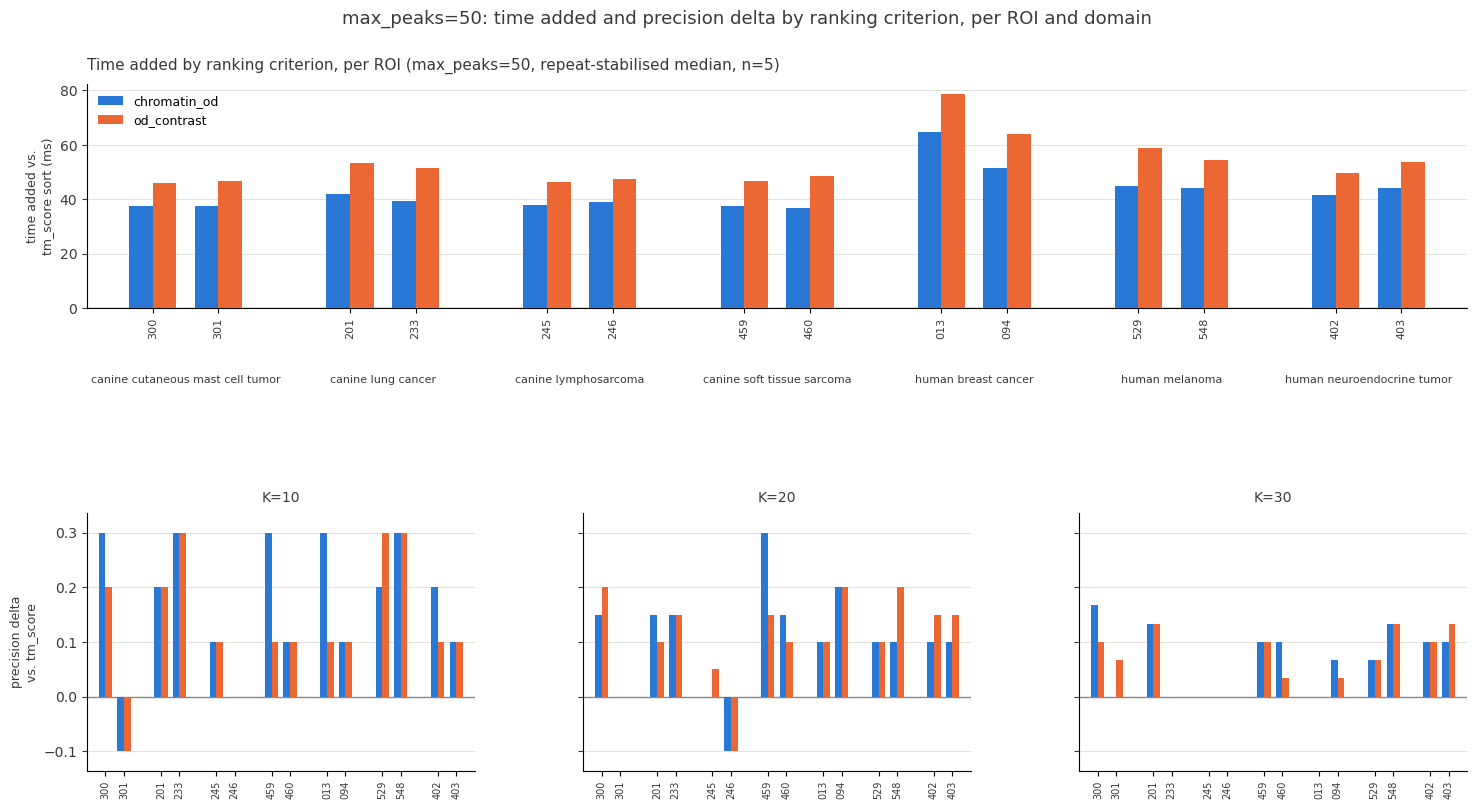

-> chromatin_od_ranker_max_peaks50_time_precision.png


In [13]:
import matplotlib.pyplot as plt

COLOR_CHROMATIN_OD = '#2a78d6'   # dataviz skill palette.md, categorical slot 1 (blue)
COLOR_OD_CONTRAST = '#eb6834'    # dataviz skill palette.md, categorical slot 2 (orange)
COLOR_ZERO_LINE = '#8a897f'
COLOR_GRID = '#e4e2dc'
COLOR_TEXT = '#3a3934'

# ---- x-axis layout: ROIs grouped by domain, with a gap between domain groups ----
domain_order = sorted(TIMING['tumor_type'].unique())
roi_order, xticks, xtick_labels, group_centers, group_labels = [], [], [], [], []
x = 0.0
for dom in domain_order:
    rois_in_dom = sorted(TIMING.index[TIMING['tumor_type'] == dom].tolist())
    start_x = x
    for fn in rois_in_dom:
        roi_order.append(fn)
        xticks.append(x)
        xtick_labels.append(fn.replace('.tiff', ''))
        x += 1
    group_centers.append((start_x + x - 1) / 2)
    group_labels.append(dom)
    x += 1  # gap between domain groups
xs = np.array(xticks)
bar_w = 0.36

# ---- Top: time added per ROI (repeat-stabilised median vs. baseline's own repeat-median sort) ----
time_added_chromatin = (TIMING.loc[roi_order, 'rep_chromatin_od_median_s']
                        - TIMING.loc[roi_order, 'rep_baseline_median_s']) * 1000
time_added_contrast = (TIMING.loc[roi_order, 'rep_od_contrast_median_s']
                       - TIMING.loc[roi_order, 'rep_baseline_median_s']) * 1000

fig = plt.figure(figsize=(15, 8.7), facecolor='white')
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.15], hspace=0.85, wspace=0.28,
                      top=0.89, bottom=0.10, left=0.06, right=0.98)

ax_top = fig.add_subplot(gs[0, :])
ax_top.bar(xs - bar_w / 2, time_added_chromatin.values, width=bar_w, color=COLOR_CHROMATIN_OD, label='chromatin_od', zorder=3)
ax_top.bar(xs + bar_w / 2, time_added_contrast.values, width=bar_w, color=COLOR_OD_CONTRAST, label='od_contrast', zorder=3)
ax_top.axhline(0, color=COLOR_ZERO_LINE, linewidth=1, zorder=2)
ax_top.set_xticks(xticks)
ax_top.set_xticklabels(xtick_labels, rotation=90, fontsize=8, color=COLOR_TEXT)
ax_top.set_xlim(xs.min() - 1, xs.max() + 1)
for gc_, gl in zip(group_centers, group_labels):
    ax_top.annotate(gl, xy=(gc_, 0), xycoords=('data', 'axes fraction'), xytext=(0, -48),
                    textcoords='offset points', ha='center', va='top', fontsize=8, color=COLOR_TEXT)
ax_top.set_ylabel('time added vs.\ntm_score sort (ms)', fontsize=9, color=COLOR_TEXT)
ax_top.set_title(f'Time added by ranking criterion, per ROI (max_peaks={MAX_PEAKS}, repeat-stabilised median, n={N_REPEATS})',
                 fontsize=11, color=COLOR_TEXT, loc='left', pad=10)
ax_top.grid(axis='y', color=COLOR_GRID, linewidth=0.8, zorder=0)
ax_top.set_axisbelow(True)
for spine in ('top', 'right'):
    ax_top.spines[spine].set_visible(False)
ax_top.legend(frameon=False, fontsize=9, loc='upper left')
ax_top.tick_params(axis='y', colors=COLOR_TEXT)

# ---- Bottom: precision delta per ROI, faceted by budget, shared y-scale ----
all_deltas = []
for k in BUDGETS_FOR_EVAL:
    base_k = PRECISION_LONG[(PRECISION_LONG['arm'] == 'tm_score') & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
    for arm in ('chromatin_od', 'od_contrast'):
        arm_k = PRECISION_LONG[(PRECISION_LONG['arm'] == arm) & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
        all_deltas.append((arm_k.loc[roi_order] - base_k.loc[roi_order]).values)
all_deltas = np.concatenate(all_deltas)
y_pad = max(0.02, 0.12 * np.abs(all_deltas).max())
y_lim = (all_deltas.min() - y_pad, all_deltas.max() + y_pad)

axes_bottom = []
for i, k in enumerate(BUDGETS_FOR_EVAL):
    ax = fig.add_subplot(gs[1, i], sharey=axes_bottom[0] if axes_bottom else None)
    base_k = PRECISION_LONG[(PRECISION_LONG['arm'] == 'tm_score') & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
    chrom_k = PRECISION_LONG[(PRECISION_LONG['arm'] == 'chromatin_od') & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
    contr_k = PRECISION_LONG[(PRECISION_LONG['arm'] == 'od_contrast') & (PRECISION_LONG['budget'] == k)].set_index('file_name')['precision_at_budget']
    d_chrom = (chrom_k.loc[roi_order] - base_k.loc[roi_order]).values
    d_contr = (contr_k.loc[roi_order] - base_k.loc[roi_order]).values
    ax.bar(xs - bar_w / 2, d_chrom, width=bar_w, color=COLOR_CHROMATIN_OD, zorder=3)
    ax.bar(xs + bar_w / 2, d_contr, width=bar_w, color=COLOR_OD_CONTRAST, zorder=3)
    ax.axhline(0, color=COLOR_ZERO_LINE, linewidth=1, zorder=2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize=7, color=COLOR_TEXT)
    ax.set_xlim(xs.min() - 1, xs.max() + 1)
    ax.set_ylim(*y_lim)
    ax.set_title(f'K={k}', fontsize=10, color=COLOR_TEXT, pad=8)
    if i == 0:
        ax.set_ylabel('precision delta\nvs. tm_score', fontsize=9, color=COLOR_TEXT)
    else:
        ax.tick_params(axis='y', labelleft=False)
    ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='y', colors=COLOR_TEXT)
    axes_bottom.append(ax)

fig.suptitle(f'max_peaks={MAX_PEAKS}: time added and precision delta by ranking criterion, per ROI and domain',
            fontsize=13, color=COLOR_TEXT, y=0.975)
fig.savefig('chromatin_od_ranker_max_peaks50_time_precision.png', dpi=150, facecolor='white')
plt.show()
print('-> chromatin_od_ranker_max_peaks50_time_precision.png')

## Closing readout

In [14]:
print(f'max_peaks={MAX_PEAKS} (D9 (DECISIONS.md) accepted 100; this is an ablation of going further), '
     f'3 ranking arms, mean over {len(TIMING)} ROIs:')
print(f'  baseline (tm_score) full pipeline: {TIMING_MS["t_baseline_pipeline_ms"].mean():.2f}ms')
for arm_label, prefix in [('chromatin_od', 'rep_chromatin_od'), ('od_contrast', 'rep_od_contrast')]:
    v = (TIMING['t_shared_stages_s'] + TIMING[f'{prefix}_median_s']).mean() * 1000
    b = (TIMING['t_shared_stages_s'] + TIMING['rep_baseline_median_s']).mean() * 1000
    print(f'  {arm_label:14s} full pipeline (repeat-stabilised): {v:.2f}ms ({v - b:+.2f}ms, {(v - b) / b * 100:+.1f}%)')

print()
print('Precision, pooled across 14 ROIs (tm_score -> chromatin_od / od_contrast):')
for k in BUDGETS_FOR_EVAL:
    b = PRECISION_LONG[(PRECISION_LONG['arm'] == 'tm_score') & (PRECISION_LONG['budget'] == k)]
    pb = b['tp_at_budget'].sum() / b['budget_delivered'].sum()
    row = f'  K={k}: {pb:.4f}'
    for arm in ['chromatin_od', 'od_contrast']:
        v = PRECISION_LONG[(PRECISION_LONG['arm'] == arm) & (PRECISION_LONG['budget'] == k)]
        pv = v['tp_at_budget'].sum() / v['budget_delivered'].sum()
        row += f'  -> {arm}={pv:.4f} ({pv - pb:+.4f})'
    print(row)

print()
print(f'Caveat (D5, restated): single-seed, n=14 -- one click per ROI, not the paired, multi-seed '
     f'sweep D5 sets as the bar for changing a production default. MAX_PEAKS={MAX_PEAKS} is a '
     f'deviation explored here, not an adopted value -- D9 (DECISIONS.md) accepted 100.')
print(f'\nnotebook ran in {time.time() - NB_T0:.0f}s')

max_peaks=50 (D9 (DECISIONS.md) accepted 100; this is an ablation of going further), 3 ranking arms, mean over 14 ROIs:
  baseline (tm_score) full pipeline: 1485.16ms
  chromatin_od   full pipeline (repeat-stabilised): 1527.78ms (+42.71ms, +2.9%)
  od_contrast    full pipeline (repeat-stabilised): 1538.27ms (+53.19ms, +3.6%)

Precision, pooled across 14 ROIs (tm_score -> chromatin_od / od_contrast):
  K=10: 0.5000  -> chromatin_od=0.6714 (+0.1714)  -> od_contrast=0.6357 (+0.1357)
  K=20: 0.4536  -> chromatin_od=0.5607 (+0.1071)  -> od_contrast=0.5643 (+0.1107)
  K=30: 0.4286  -> chromatin_od=0.4976 (+0.0690)  -> od_contrast=0.4929 (+0.0643)

Caveat (D5, restated): single-seed, n=14 -- one click per ROI, not the paired, multi-seed sweep D5 sets as the bar for changing a production default. MAX_PEAKS=50 is a deviation explored here, not an adopted value -- D9 (DECISIONS.md) accepted 100.

notebook ran in 85s
